<a href="https://colab.research.google.com/github/GunaSamhith/ML-labActivity/blob/main/7_6_DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
import pandas as pd

data = pd.DataFrame({
    'Age': [25, 30, 35, 40, 45, 50, 55, 60],
    'Income': [30, 40, 50, 60, 70, 80, 90, 100],
    'Buy_House': [0, 0, 0, 1, 1, 1, 1, 1]
})

X = data[['Age', 'Income']]
y = data['Buy_House']

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(X, y)

print(export_text(model, feature_names=['Age', 'Income']))

|--- Income <= 55.00
|   |--- class: 0
|--- Income >  55.00
|   |--- class: 1



Dataset:


,Age,Income,Buy_House
0,22,25,0
1,25,30,0
2,28,35,0
3,31,40,1
4,32,45,1
5,35,50,1
6,38,55,1
7,40,60,1
8,45,65,1
9,50,70,1



Decision Tree Rules:
|--- Income <= 37.50
|   |--- class: 0
|--- Income >  37.50
|   |--- class: 1


Predicted values:
[0 0 0 1 1 1 1 1 1 1 1 1]

Accuracy: 1.0


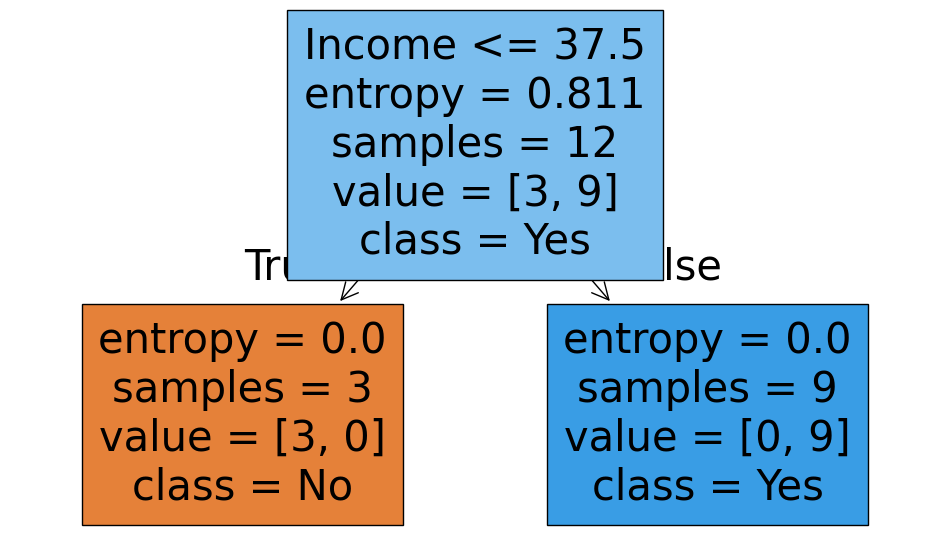

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Creating dataset
data = pd.DataFrame({
    'Age': [22, 25, 28, 31, 32, 35, 38, 40, 45, 50, 55, 60],
    'Income': [25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 80, 90],
    'Buy_House': [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]
})

print("Dataset:")
display(data)

# Independent variables
X = data[['Age', 'Income']]

# Dependent variable
y = data['Buy_House']

# Create Decision Tree
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=5
)

# Train the model
model.fit(X, y)

# Display tree rules
from sklearn.tree import export_text

print("\nDecision Tree Rules:")
print(export_text(model, feature_names=['Age', 'Income']))

# Predict
y_pred = model.predict(X)

print("\nPredicted values:")
print(y_pred)

# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)

print("\nAccuracy:", accuracy)

# Visualize Decision Tree
plt.figure(figsize=(12, 7))

plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()

Dataset:


,Weather,Friends,Free_Time,Decision
0,Sunny,Yes,Yes,Go Out
1,Sunny,Yes,No,Go Out
2,Sunny,No,Yes,Go Out
3,Sunny,No,No,Stay In
4,Rainy,Yes,Yes,Stay In
5,Rainy,No,No,Stay In
6,Rainy,Yes,Yes,Go Out
7,Rainy,No,No,Stay In
8,Cloudy,Yes,Yes,Go Out
9,Cloudy,Yes,No,Stay In



Predicted values:
[1 1 1 0 0 0 0 0 1 0 0 0]

Accuracy: 0.9166666666666666
Accuracy in Percentage: 91 %

Prediction: GO OUT


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


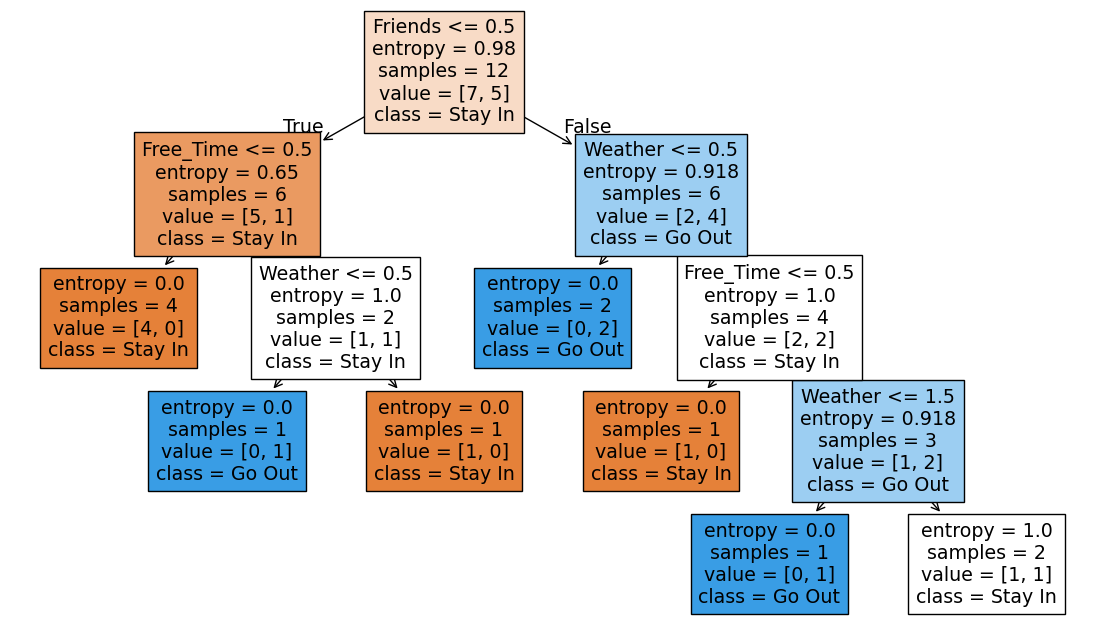

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Creating dataset
data = pd.DataFrame({
    'Weather': [
        'Sunny', 'Sunny', 'Sunny', 'Sunny',
        'Rainy', 'Rainy', 'Rainy', 'Rainy',
        'Cloudy', 'Cloudy', 'Cloudy', 'Cloudy'
    ],

    'Friends': [
        'Yes', 'Yes', 'No', 'No',
        'Yes', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'No', 'No'
    ],

    'Free_Time': [
        'Yes', 'No', 'Yes', 'No',
        'Yes', 'No', 'Yes', 'No',
        'Yes', 'No', 'Yes', 'No'
    ],

    'Decision': [
        'Go Out', 'Go Out', 'Go Out', 'Stay In',
        'Stay In', 'Stay In', 'Go Out', 'Stay In',
        'Go Out', 'Stay In', 'Stay In', 'Stay In'
    ]
})

print("Dataset:")
display(data)

# Convert categorical values into numbers

data['Weather'] = data['Weather'].map({
    'Sunny': 0,
    'Cloudy': 1,
    'Rainy': 2
})

data['Friends'] = data['Friends'].map({
    'No': 0,
    'Yes': 1
})

data['Free_Time'] = data['Free_Time'].map({
    'No': 0,
    'Yes': 1
})

data['Decision'] = data['Decision'].map({
    'Stay In': 0,
    'Go Out': 1
})

# Independent variables
X = data[['Weather', 'Friends', 'Free_Time']]

# Dependent variable
y = data['Decision']

# Create Decision Tree
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

# Train model
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("\nPredicted values:")
print(y_pred)

# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy in Percentage:", int(accuracy * 100), "%")

# Predict a new situation
# Sunny + Friends = Yes + Free Time = Yes
new_data = [[0, 1, 1]]

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("\nPrediction: GO OUT")
else:
    print("\nPrediction: STAY IN")

# Display decision tree
plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=['Weather', 'Friends', 'Free_Time'],
    class_names=['Stay In', 'Go Out'],
    filled=True
)

plt.show()